# Native EOS-CG-2021 validation

This notebook validates the native PyTorch EOS-CG-2021 Helmholtz
implementation at four levels:

1. the complete published mixture inventory (16 components, 120 binary
   reducing rules, and 21 non-zero departure functions);
2. 36 CO2/H2 states generated independently with `teqp` 0.23.2 from the
   EOS-CG-2021 coefficient tables;
3. all 35 experimental liquid-density points for MDEA reported by Neumann
   et al. and used by EOS-CG-2021.
4. all 44 experimental MDEA speed-of-sound points, which exercise the full
   ideal part and second Helmholtz derivatives.

The frozen reference CSVs make this notebook reproducible without an
external thermodynamic package. They are data, not fitted targets.

Sources:

- EOS-CG-2021: <https://doi.org/10.1007/s10765-023-03263-6>
- EOS-CG-2021 supplementary coefficient tables:
  <https://static-content.springer.com/esm/art%3A10.1007%2Fs10765-023-03263-6/MediaObjects/10765_2023_3263_MOESM1_ESM.pdf>
- MDEA EOS, Table 1 density data, and Tables 4–5 speed-of-sound data:
  <https://doi.org/10.1007/s10765-021-02933-7>
- `teqp` multifluid formulation:
  <https://pages.nist.gov/teqp-docs/en/main/models/multifluid.html>

Scope: the native constructor evaluates the complete pure-fluid ideal and
residual equations together with the complete mixture parameter set.
Consequently caloric properties and speed of sound are included alongside
pressure, density, compressibility, chemical potentials, and fugacity.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from torch_flash.eos import EOSCG2021_COMPONENTS, eoscg2021

torch.set_default_dtype(torch.float64)
REPO_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").is_file()
)
DATA = REPO_ROOT / "tests" / "data"
plt.style.use("seaborn-v0_8-whitegrid")

## Published parameter inventory

There are ${16 \choose 2}=120$ binary pairs. A non-zero departure scale
denotes a pair with an explicit binary departure function; every other pair
still has its published reducing parameters.

In [2]:
full_model = eoscg2021()
inventory = pd.Series(
    {
        "components": len(full_model.names),
        "binary reducing-parameter sets": len(full_model.names)
        * (len(full_model.names) - 1)
        // 2,
        "non-zero departure functions": int(
            torch.count_nonzero(
                torch.triu(full_model.departure_scale, diagonal=1)
            ).item()
        ),
    },
    name="EOS-CG-2021",
)
display(inventory.to_frame())
print(", ".join(EOSCG2021_COMPONENTS))

assert inventory.to_dict() == {
    "components": 16,
    "binary reducing-parameter sets": 120,
    "non-zero departure functions": 21,
}

,EOS-CG-2021
components,16
binary reducing-parameter sets,120
non-zero departure functions,21


carbon_dioxide, water, nitrogen, oxygen, argon, carbon_monoxide, hydrogen, methane, hydrogen_sulfide, sulfur_dioxide, mea, dea, hydrogen_chloride, chlorine, ammonia, mdea


## Independent dense CO2/H2 numerical reference

The grid spans three compositions, three temperatures, and four molar
densities. Both the residual Helmholtz energy and its density derivative
(through pressure) are checked. Matching pressure is a stricter test than
comparing only the potential because it exercises PyTorch autodiff.

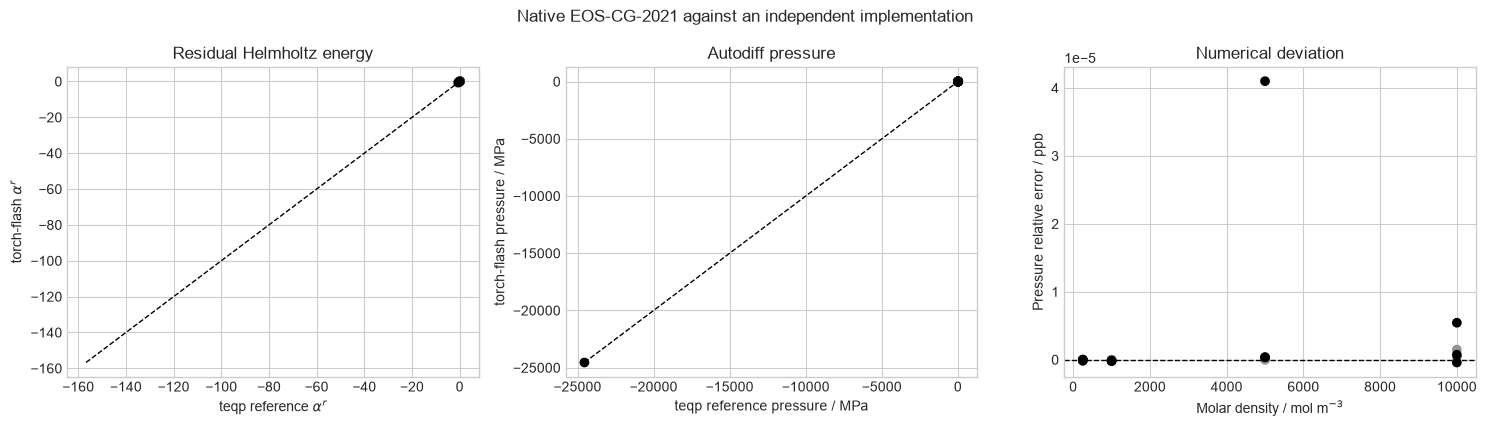

,value
max |alpha error|,7.105427e-13
max |pressure relative error| / ppb,4.099572e-05


In [3]:
co2_h2 = pd.read_csv(DATA / "eoscg2021_co2_h2_teqp_reference.csv")
binary_model = eoscg2021(("CO2", "H2"))

alpha_predicted: list[float] = []
pressure_predicted: list[float] = []
for row in co2_h2.itertuples(index=False):
    composition = torch.tensor([row.co2_mole_fraction, 1.0 - row.co2_mole_fraction])
    temperature = torch.tensor(row.temperature_K)
    density = torch.tensor(row.molar_density_mol_m3)
    alpha_predicted.append(
        float(binary_model.alpha_residual(temperature, density, composition))
    )
    pressure_predicted.append(
        float(binary_model.pressure(temperature, density.reciprocal(), composition))
    )

co2_h2["alpha_predicted"] = alpha_predicted
co2_h2["pressure_predicted_Pa"] = pressure_predicted
co2_h2["alpha_error"] = co2_h2["alpha_predicted"] - co2_h2["alpha_residual"]
co2_h2["pressure_relative_error_ppb"] = (
    1.0e9
    * (co2_h2["pressure_predicted_Pa"] - co2_h2["pressure_Pa"])
    / co2_h2["pressure_Pa"]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].scatter(
    co2_h2["alpha_residual"], co2_h2["alpha_predicted"], c=co2_h2["temperature_K"]
)
alpha_limits = [
    co2_h2[["alpha_residual", "alpha_predicted"]].min().min(),
    co2_h2[["alpha_residual", "alpha_predicted"]].max().max(),
]
axes[0].plot(alpha_limits, alpha_limits, "k--", linewidth=1)
axes[0].set(
    xlabel="teqp reference $\\alpha^r$",
    ylabel="torch-flash $\\alpha^r$",
    title="Residual Helmholtz energy",
)

axes[1].scatter(
    co2_h2["pressure_Pa"] / 1.0e6,
    co2_h2["pressure_predicted_Pa"] / 1.0e6,
    c=co2_h2["co2_mole_fraction"],
)
pressure_limits = [
    co2_h2[["pressure_Pa", "pressure_predicted_Pa"]].min().min() / 1.0e6,
    co2_h2[["pressure_Pa", "pressure_predicted_Pa"]].max().max() / 1.0e6,
]
axes[1].plot(pressure_limits, pressure_limits, "k--", linewidth=1)
axes[1].set(
    xlabel="teqp reference pressure / MPa",
    ylabel="torch-flash pressure / MPa",
    title="Autodiff pressure",
)

axes[2].scatter(
    co2_h2["molar_density_mol_m3"],
    co2_h2["pressure_relative_error_ppb"],
    c=co2_h2["co2_mole_fraction"],
)
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set(
    xlabel="Molar density / mol m$^{-3}$",
    ylabel="Pressure relative error / ppb",
    title="Numerical deviation",
)
fig.suptitle("Native EOS-CG-2021 against an independent implementation")
fig.tight_layout()
plt.show()

co2_h2_metrics = pd.Series(
    {
        "max |alpha error|": co2_h2["alpha_error"].abs().max(),
        "max |pressure relative error| / ppb": co2_h2["pressure_relative_error_ppb"]
        .abs()
        .max(),
    }
)
display(co2_h2_metrics.to_frame("value"))
assert co2_h2["alpha_error"].abs().max() < 1.0e-12
assert co2_h2["pressure_relative_error_ppb"].abs().max() < 1.0e-4

## MDEA liquid density against experiment

The 35 measurements cover approximately 300--360 K and 0.09--95 MPa.
Expanded experimental uncertainty is 1.3 kg m$^{-3}$ (about 0.12%). The
model parameters are those of the MDEA EOS incorporated into EOS-CG-2021;
no parameter is fitted in this notebook.

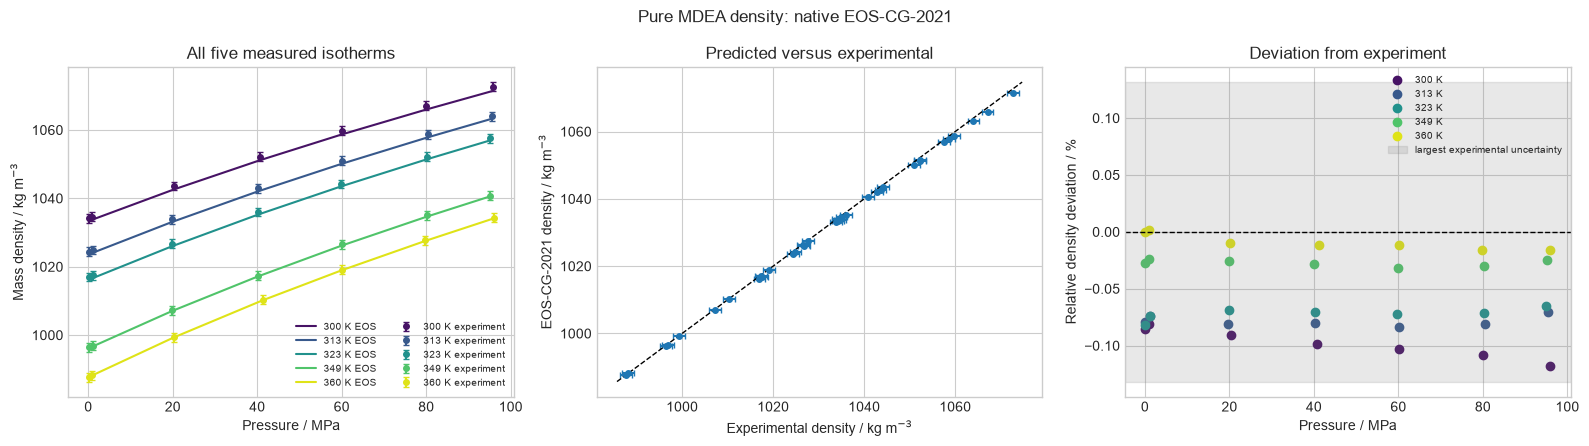

,value
number of experimental states,35.000000
AARD / %,0.057046
maximum absolute relative deviation / %,0.117824
maximum experimental relative uncertainty / %,0.131619


In [4]:
mdea_data = pd.read_csv(DATA / "eoscg2021_mdea_density_experimental.csv")
mdea_model = eoscg2021(("MDEA",))

density_predicted: list[float] = []
for row in mdea_data.itertuples(index=False):
    volume = mdea_model.molar_volume(
        torch.tensor(row.temperature_K),
        torch.tensor(row.pressure_Pa),
        torch.ones(1),
        "liquid",
    )
    density_predicted.append(float(mdea_model.molar_mass[0] / volume))

mdea_data["predicted_density_kg_m3"] = density_predicted
mdea_data["relative_deviation_percent"] = (
    100.0
    * (mdea_data["predicted_density_kg_m3"] - mdea_data["density_kg_m3"])
    / mdea_data["density_kg_m3"]
)
mdea_data["nominal_temperature_K"] = mdea_data["temperature_K"].round().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = plt.cm.viridis(
    torch.linspace(0.05, 0.95, mdea_data["nominal_temperature_K"].nunique()).numpy()
)
for color, (temperature, group) in zip(
    colors, mdea_data.groupby("nominal_temperature_K"), strict=True
):
    group = group.sort_values("pressure_Pa")
    label = f"{temperature} K"
    axes[0].errorbar(
        group["pressure_Pa"] / 1.0e6,
        group["density_kg_m3"],
        yerr=group["expanded_uncertainty_kg_m3"],
        fmt="o",
        color=color,
        markersize=4,
        capsize=2,
        label=f"{label} experiment",
    )
    axes[0].plot(
        group["pressure_Pa"] / 1.0e6,
        group["predicted_density_kg_m3"],
        color=color,
        linewidth=1.5,
        label=f"{label} EOS",
    )
    axes[2].scatter(
        group["pressure_Pa"] / 1.0e6,
        group["relative_deviation_percent"],
        color=color,
        label=label,
    )

axes[0].set(
    xlabel="Pressure / MPa",
    ylabel="Mass density / kg m$^{-3}$",
    title="All five measured isotherms",
)
axes[0].legend(ncol=2, fontsize=7)

axes[1].errorbar(
    mdea_data["density_kg_m3"],
    mdea_data["predicted_density_kg_m3"],
    xerr=mdea_data["expanded_uncertainty_kg_m3"],
    fmt="o",
    markersize=4,
    capsize=2,
)
density_limits = [
    mdea_data[["density_kg_m3", "predicted_density_kg_m3"]].min().min() - 2.0,
    mdea_data[["density_kg_m3", "predicted_density_kg_m3"]].max().max() + 2.0,
]
axes[1].plot(density_limits, density_limits, "k--", linewidth=1)
axes[1].set(
    xlabel="Experimental density / kg m$^{-3}$",
    ylabel="EOS-CG-2021 density / kg m$^{-3}$",
    title="Predicted versus experimental",
)

relative_uncertainty = (
    100.0 * mdea_data["expanded_uncertainty_kg_m3"] / mdea_data["density_kg_m3"]
)
uncertainty_bound = relative_uncertainty.max()
axes[2].axhspan(
    -uncertainty_bound,
    uncertainty_bound,
    color="gray",
    alpha=0.18,
    label="largest experimental uncertainty",
)
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set(
    xlabel="Pressure / MPa",
    ylabel="Relative density deviation / %",
    title="Deviation from experiment",
)
axes[2].legend(fontsize=7)
fig.suptitle("Pure MDEA density: native EOS-CG-2021")
fig.tight_layout()
plt.show()

mdea_metrics = pd.Series(
    {
        "number of experimental states": len(mdea_data),
        "AARD / %": mdea_data["relative_deviation_percent"].abs().mean(),
        "maximum absolute relative deviation / %": mdea_data[
            "relative_deviation_percent"
        ]
        .abs()
        .max(),
        "maximum experimental relative uncertainty / %": uncertainty_bound,
    }
)
display(mdea_metrics.to_frame("value"))
assert len(mdea_data) == 35
assert mdea_data["relative_deviation_percent"].abs().mean() < 0.06
assert mdea_data["relative_deviation_percent"].abs().max() < 0.13

## MDEA speed of sound: a derivative-intensive experimental check

Tables 4 and 5 of the MDEA source paper contain 44 measurements from two
pulse-echo apparatuses. Speed of sound exercises first and second
temperature/density derivatives of both the ideal and residual Helmholtz
terms. The paper assigns a 0.09% uncertainty to this property over the
measured range.

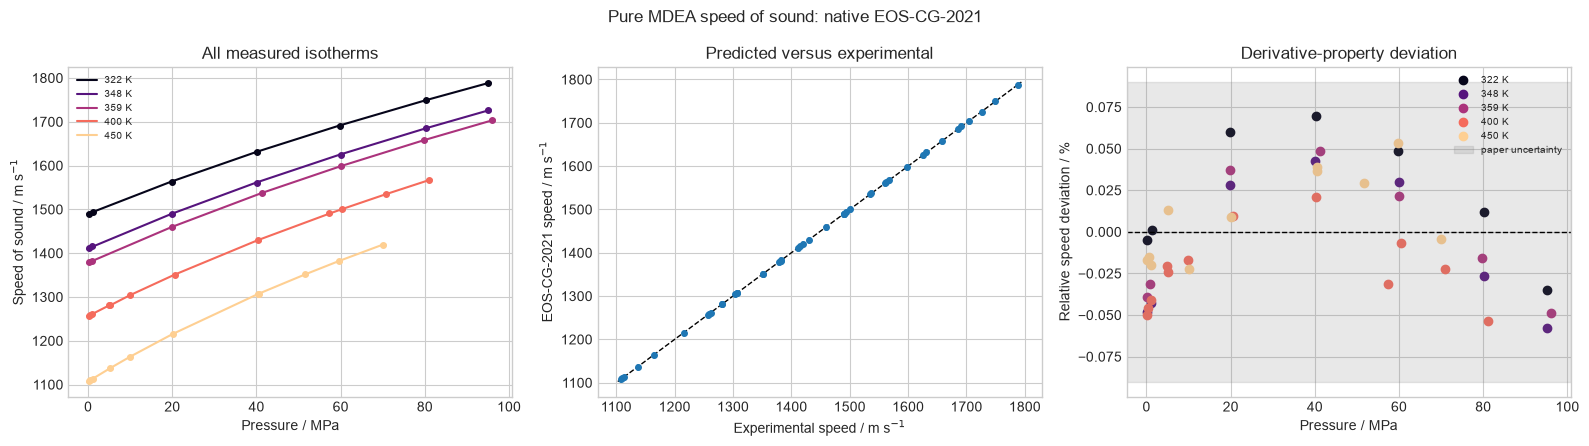

,value
number of experimental states,44.000000
AARD / %,0.030653
maximum absolute relative deviation / %,0.069770


In [5]:
sound_data = pd.read_csv(DATA / "eoscg2021_mdea_speed_of_sound_experimental.csv")
sound_predicted: list[float] = []
for row in sound_data.itertuples(index=False):
    temperature = torch.tensor(row.temperature_K)
    pressure = torch.tensor(row.pressure_Pa)
    volume = mdea_model.molar_volume(
        temperature,
        pressure,
        torch.ones(1),
        "liquid",
    )
    sound_predicted.append(
        float(
            mdea_model.speed_of_sound(
                temperature,
                volume.reciprocal(),
                torch.ones(1),
            )
        )
    )

sound_data["predicted_speed_m_s"] = sound_predicted
sound_data["relative_deviation_percent"] = (
    100.0
    * (sound_data["predicted_speed_m_s"] - sound_data["speed_of_sound_m_s"])
    / sound_data["speed_of_sound_m_s"]
)
sound_data["nominal_temperature_K"] = sound_data["temperature_K"].round().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sound_colors = plt.cm.magma(
    torch.linspace(0.05, 0.9, sound_data["nominal_temperature_K"].nunique()).numpy()
)
for color, (temperature, group) in zip(
    sound_colors,
    sound_data.groupby("nominal_temperature_K"),
    strict=True,
):
    group = group.sort_values("pressure_Pa")
    axes[0].errorbar(
        group["pressure_Pa"] / 1.0e6,
        group["speed_of_sound_m_s"],
        yerr=group["expanded_uncertainty_m_s"],
        fmt="o",
        color=color,
        markersize=4,
        capsize=2,
    )
    axes[0].plot(
        group["pressure_Pa"] / 1.0e6,
        group["predicted_speed_m_s"],
        color=color,
        label=f"{temperature} K",
    )
    axes[2].scatter(
        group["pressure_Pa"] / 1.0e6,
        group["relative_deviation_percent"],
        color=color,
        label=f"{temperature} K",
    )
axes[0].set(
    xlabel="Pressure / MPa",
    ylabel="Speed of sound / m s$^{-1}$",
    title="All measured isotherms",
)
axes[0].legend(fontsize=7)

axes[1].errorbar(
    sound_data["speed_of_sound_m_s"],
    sound_data["predicted_speed_m_s"],
    xerr=sound_data["expanded_uncertainty_m_s"],
    fmt="o",
    markersize=4,
    capsize=2,
)
sound_limits = [
    sound_data[["speed_of_sound_m_s", "predicted_speed_m_s"]].min().min() - 5.0,
    sound_data[["speed_of_sound_m_s", "predicted_speed_m_s"]].max().max() + 5.0,
]
axes[1].plot(sound_limits, sound_limits, "k--", linewidth=1)
axes[1].set(
    xlabel="Experimental speed / m s$^{-1}$",
    ylabel="EOS-CG-2021 speed / m s$^{-1}$",
    title="Predicted versus experimental",
)

axes[2].axhspan(-0.09, 0.09, color="gray", alpha=0.18, label="paper uncertainty")
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set(
    xlabel="Pressure / MPa",
    ylabel="Relative speed deviation / %",
    title="Derivative-property deviation",
)
axes[2].legend(fontsize=7)
fig.suptitle("Pure MDEA speed of sound: native EOS-CG-2021")
fig.tight_layout()
plt.show()

sound_metrics = pd.Series(
    {
        "number of experimental states": len(sound_data),
        "AARD / %": sound_data["relative_deviation_percent"].abs().mean(),
        "maximum absolute relative deviation / %": sound_data[
            "relative_deviation_percent"
        ]
        .abs()
        .max(),
    }
)
display(sound_metrics.to_frame("value"))
assert len(sound_data) == 44
assert sound_data["relative_deviation_percent"].abs().mean() < 0.031
assert sound_data["relative_deviation_percent"].abs().max() < 0.07

## Differentiability of a published mixture parameter

Trainable constructors expose coefficient tensors as `torch.nn.Parameter`
objects. Here the pressure sensitivity to the CO2/H2 departure scale is
obtained directly by reverse-mode autodiff.

In [6]:
trainable_model = eoscg2021(("CO2", "H2"), trainable=True)
state_temperature = torch.tensor(300.0)
state_density = torch.tensor(5_000.0)
state_composition = torch.tensor([0.5, 0.5])
state_pressure = trainable_model.pressure(
    state_temperature, state_density.reciprocal(), state_composition
)
state_pressure.backward()

sensitivity = trainable_model.departure_scale.grad[0, 1]
print(
    "dP/dF_CO2,H2 = "
    f"{float(sensitivity):.6g} Pa per unit departure-scale coefficient"
)
assert torch.isfinite(sensitivity)

dP/dF_CO2,H2 = 85390.3 Pa per unit departure-scale coefficient


## Interpretation and limitations

- The independent numerical reference is reproduced at floating-point
  precision, including the pressure derivative.
- All 35 MDEA density points lie within 0.13% relative deviation, with an
  AARD below 0.06%.
- All 44 MDEA speed-of-sound points lie within 0.07%, requiring the complete
  ideal part and second Helmholtz derivatives.
- This validates the states and properties exercised here; it is not a
  universal accuracy claim for all EOS-CG mixtures. The EOS-CG-2021 paper,
  for example, reports appreciably larger speed-of-sound deviations for
  some CO2/H2 data.